![NLP Overview](image-6.png)

In [1]:
# load the spacy english model
import spacy
nlp = spacy.load('en_core_web_sm')

# view a single phrase
phrase = 'im selling lemons for $5 today!@$'
phrase
# create a spacy doc object
doc = nlp(phrase)
doc


im selling lemons for $5 today!@$

NLP Pipeline: 

- A. Text Preprocessing with Pandas or
- A. Text Preprocessing with spaCy
- B. Vectorization

#### A: TEXT PREPROCESSING WITH SPACY

- A.1)Tokenize the text
- A.2)Lemmatize the text
- A.3)Remove stop words

#### A.1. TOKENIZATION [break text up into smaller units, like words]
Text strings are often split by whitespace to make tokens

In [2]:
[token.text for token in doc]

['i', 'm', 'selling', 'lemons', 'for', '$', '5', 'today!@$']

spaCy mainly splits on whitespace, but there’s some additional, smarter logic:

- Common contractions are separated (I’m)
- Punctuation is typically separated unless it’s a URL, email address, etc.
- …and much more!

#### A.2. LEMMATIZATION

Lemmatization reduces words to their base form spaCy uses a combination of linguistic rules and statistical models to lemmatize text

With lemmatization:

- “i” has been updated to “I”
- “selling” has been updated to “sell”
- “lemons” has been updated to “lemon”

**What’s the difference between lemmatization and stemming?**

The key difference is that stemming is a fast, rule‑based truncation of words that may produce non‑dictionary forms, while lemmatization is a linguistically accurate process that uses vocabulary and grammar to return the proper base word (lemma).

- Stemming  Output: Produces a “stem” that may not be a valid word.
- Stemming: am → am, is → is, are → ar happy → happi, happiness → happi
- running → run; studies → studi;   communication → commun

- They both reduce words to their base form, but lemmatization is the smarter approachand generally performs better – when choosing one, go with lemmatization
- lemmatization Output: Returns the correct dictionary form (lemma).
- Lemmatization: am → be, is → be, are → be happy → happy, happiness → happy
- running → run (verb)  better → good (adjective)   studies → study

**Stemming**:
- Speed: Very fast, computationally cheap. Accuracy: Lower, ignores context.
- Use Cases: Search engines, document indexing, keyword matching where recall is more important than precision.

**Lemmatization**:
- Speed: Slower, more computationally expensive.Accuracy: Higher, context‑aware.
- Use Cases: Sentiment analysis, machine translation, chatbots, tasks where semantic accuracy matters.

In [3]:
# lemmatize the tokens to their root form
[token.lemma_ for token in doc]

['I', 'm', 'sell', 'lemon', 'for', '$', '5', 'today!@$']

#### A.3. STOP WORDS

Stop words in NLP are common words (like “the”, “is”, “and”) that occur frequently but carry little meaningful information. They are usually removed during preprocessing to reduce noise and improve model performance, especially in tasks like text classification and sentiment analysis.

**Why Remove Stop Words?**
- Efficiency: Reduces dataset size and speeds up training.
- Improved Accuracy: Prevents common words from skewing results.
- Cleaner Features: Makes vectorization (Bag‑of‑Words, TF‑IDF) more meaningful.


**Stop word**s are words without any significant meaning. You can view the full stop word list in spaCy with the code print(nlp.Defaults.stop_words).

In [4]:
# remove the stop words
norm = [token.lemma_ for token in doc if not token.is_stop]
norm


['m', 'sell', 'lemon', '$', '5', 'today!@$']

#### A.4. PARTS OF SPEECH TAGGING

Parts of speech (POS) tagging lets you label nouns, verbs, etc. within text data.
This is optional, but is sometimes used as a filtering technique to only look at nouns and pronouns for analysis, for example.

token.text → gives the actual word/token from the document.

token.pos_ → provides the part‑of‑speech tag (e.g., noun, verb, adjective).

In [5]:
# view the parts of speech tags
pos = [(token.text, token.pos_) for token in doc]
pos


[('i', 'PRON'),
 ('m', 'AUX'),
 ('selling', 'VERB'),
 ('lemons', 'NOUN'),
 ('for', 'ADP'),
 ('$', 'SYM'),
 ('5', 'NUM'),
 ('today!@$', 'NOUN')]

#### A.5 linguistic feature in spaCy

In spaCy, “linguistic features” are the annotations it automatically adds to text—things like tokens, lemmas, part‑of‑speech tags, syntactic dependencies, and named entities. These features transform raw text into structured data that you can analyze or feed into machine learning models.

When you process text with nlp = spacy.load("en_core_web_sm"), the resulting Doc object contains rich attributes for each token:

- Text (token.text) – the original word.
- Lemma (token.lemma_) – the base/root form (running → run).
- Part‑of‑Speech (token.pos_) – coarse grammatical role (NOUN, VERB, ADJ).
- Detailed Tag (token.tag_) – fine‑grained POS tag (VBZ = verb, 3rd person singular present).
- Dependency (token.dep_) – syntactic relation (nsubj, dobj, ROOT).
- Shape (token.shape_) – word shape (Xxxxx, xx, dddd).
- is_alpha – whether the token is alphabetic.
- is_stop – whether the token is a stop word.
- Named Entities (doc.ents) – recognized entities like people, organizations, dates.

Why Linguistic Features Matter?

- Text Classification – POS tags and lemmas reduce noise.
- Information Extraction – Named entities identify people, places, amounts.
- Sentiment Analysis – Lemmas + stop word removal improve accuracy.
- Chatbots/Assistants – Dependency parsing helps understand intent.

In [6]:
nlp = spacy.load("en_core_web_sm")
doc = nlp("Apple is looking at buying U.K. startup for $1 billion")

for tokenX_ in doc:
    print(tokenX_.text, tokenX_.lemma_, tokenX_.pos_, tokenX_.tag_, tokenX_.dep_, tokenX_.is_stop)

print(tokenX_.shape_)

Apple Apple PROPN NNP nsubj False
is be AUX VBZ aux True
looking look VERB VBG ROOT False
at at ADP IN prep True
buying buy VERB VBG pcomp False
U.K. U.K. PROPN NNP nsubj False
startup startup VERB VBD ccomp False
for for ADP IN prep True
$ $ SYM $ quantmod False
1 1 NUM CD compound False
billion billion NUM CD pobj False
xxxx


#### B. VECTORIZATION

Vectorization is the process of converting text data into numeric data so that future data analysis and machine learning techniques can be applied. Common techniques include One‑Hot Encoding, Bag‑of‑Words, TF‑IDF, and modern word embeddings like Word2Vec, GloVe, and contextual embeddings (BERT, GPT).

- Most ML techniques require text data to be cleaned, normalized and in a numeric format
- Some techniques, such as sentiment analysis, require text data to be in its raw text form

Major Vectorization Techniques:

1. One‑Hot Encoding
2. Bag‑of‑Words (BoW) [Word Counts] [CountVectorizer] [DTM]
3. TF‑IDF (Term Frequency–Inverse Document Frequency)
4. Word Embeddings (Word2Vec, GloVe)
5. Contextual Embeddings (BERT, GPT, Transformer models)

![vectorization techniques](image-1.png)

#### B.1 Document-Term Matrix (DTM) for vectorization (Bag‑of‑Words (BoW)):

A DTM is a bag of words representation of text, where each document is represented by how often certain words appear, regardless of word order.

Clean, normalized text is turned into a ***Document-Term Matrix (DTM)*** for vectorization.
- Each row represents a document, and each column represents a term.
- The values within the DTM can be word counts, TF-IDF scores, or other calculated values.

Example:
Suppose we have 3 documents:

1. "The cat sat on the mat"
2. "The dog barked at the cat"
3. "The cat and the dog sat together"

Vocabulary
["the", "cat", "sat", "on", "mat", "dog", "barked", "at", "and", "together"]

#### Document‑Term Matrix:

![Document‑Term Matrix](image-2.png)

#### How to Obtained Document term matrix (DTM) ?

To fully grasp the concept of a Document‑Term Matrix (DTM), it’s important to also understand topic modeling techniques such as Non‑Negative Matrix Factorization (NMF).

#### B.1.1 Topic Modeling

**Qus: What is Topic Modeling?**

Topic modeling is the process of finding hidden themes or topics in a large collection of text documents. Instead of manually labeling, the algorithm automatically groups words that frequently occur together, revealing patterns in the corpus.

Topic modeling helps find themes in unlabeled text documents.
Examples:

“I like lemons and limes.” → Topic 1: 100%, Topic 2: 0%

“Puppies and kittens are so cute.” → Topic 1: 0%, Topic 2: 100%

“I’m making cat‑shaped cookies.” → Topic 1: 50%, Topic 2: 50%

“My dog loves apples and blueberries.” → Topic 1: 67%, Topic 2: 33%

#### **What are topics 1 and 2?**

Topic 1: lemons, limes, cookies, apples, blueberries → Food

Topic 2: puppies, kittens, cat, dog → Animals

Technique:** Unsupervised learning**: No labeled data is required. The algorithm discovers structure on its own.  Example methods: **NMF** (Non‑negative Matrix Factorization), **LDA** (Latent Dirichlet Allocation).

##### B.1.2 Non-Negative Matrix Factorization is a popular topic modeling technique
- **NMF** is a good starting point for identifying topics within small data sets (<10k rows)
- Non‑Negative Matrix Factorization (NMF) in NLP is a mathematical technique that decomposes a document‑term matrix into two smaller non‑negative matrices, revealing latent topics. It’s widely used for topic modeling because it produces interpretable results where each topic is a distribution over words and each document is a mixture of topics.

Mathematical Foundation of NMF:

Given a document‑term matrix DTM
𝑉
 of size 
𝑚
×
𝑛
 (where 
𝑚
 = number of documents, 
𝑛
 = vocabulary size):

𝑉
≈
𝑊
⋅
𝐻

𝑉
 → Original matrix (word counts or TF‑IDF scores).

𝑊
 → Document‑topic matrix (
𝑚
×
𝑘
). Each row shows how much each topic contributes to a document.

𝐻
 → Topic‑term matrix (
𝑘
×
𝑛
). Each row shows how strongly each word belongs to a topic.

𝑘 → Number of topics chosen.

the value of 𝑘 (number of topics) in NMF is chosen by the developer or data scientist.

#### Why You Choose 𝑘?
NMF doesn’t automatically decide how many topics exist. You set 𝑘 based on:

- **Domain knowledge** (e.g., you expect 3 themes in customer reviews: product, delivery, service).
- **Experimentation** (try different 𝑘 values and compare results).
- **Evaluation metrics** (topic coherence, reconstruction error, interpretability).

#### B.1.2.1 Statistical Methods to Choose 𝑘:

##### Choosing the Number of Topics (k) in NMF

We want to find the optimal number of topics `k` for Non-Negative Matrix Factorization (NMF).
Two common statistical methods are:

1. **Reconstruction Error**
   - Minimize the Frobenius norm:
   - $\min_{W,H} \| V - W \cdot H \|_F^2$
   - Plot error vs. k and look for the "elbow point".

2. **Topic Coherence**
   - Evaluate semantic consistency of top words in each topic.
   - Higher coherence = more interpretable topics.
3. Perplexity (for probabilistic models like LDA)
   - While NMF doesn’t directly use perplexity, you can compare with LDA results.
   - Lower perplexity = better generalization.
4. **Cross‑Validation**:
   - Split documents into train/test sets.
   - Fit NMF with different 𝑘.
   - Evaluate how well topics reconstruct unseen documents.
5. **Information Criteria (AIC/BIC)**:
   - Adapted from model selection in statistics.
   - Penalizes overly complex models (large 𝑘).

The constraint:

$𝑊 ≥ 0,𝐻 ≥ 0$

The goal is to minimize the reconstruction error:

$\min_{W,H} \| V - W \cdot H \|_F^2$
- where $\| \cdot \|_F $ is the Frobenius norm (sum of squared differences).

To solve the optimization, NMF uses iterative multiplicative updates:

$H_{ij} \leftarrow H_{ij} \cdot \frac{(W^T V)_{ij}}{(W^T W H)_{ij}}$

$
W_{ij} \leftarrow W_{ij} \cdot \frac{(V H^T)_{ij}}{(W H H^T)_{ij}}$

These updates refine $W$ and $H$ until convergence.



#### step by step how the matrices 𝑊 and 𝐻 are filled in NMF

- Suppose we have 3 documents:
    - D1: "tea and coffee"
    - D2: "coffee and sports"
    - D3: "tea and sports"

Vocabulary = {tea, coffee, sports}

Step 1: Start with Document-Term Matrix (DTM)
$V =
\begin{bmatrix}
1 & 1 & 0 \\
0 & 1 & 1 \\
1 & 0 & 1
\end{bmatrix}$

Step 2: Choose number of topics (k = 2)
- → $W$ will be (documents × topics) = $3 \times 2$
- → $H$ will be (topics × terms) = $2 \times 3$

Step 3: Initialize W and H (non-negative values)[NMF starts with random non‑negative values in W & H]
- $W =
\begin{bmatrix}
0.9 & 0.1 \\
0.2 & 0.8 \\
0.7 & 0.6
\end{bmatrix}$
- $H =
\begin{bmatrix}
1.0 & 0.8 & 0.1 \\
0.1 & 0.5 & 0.9
\end{bmatrix}$

Step 4: NMF update rules (iterative refinement)
- $H \leftarrow H \cdot \frac{W^T V}{W^T W H}$
- $W \leftarrow W \cdot \frac{V H^T}{W H H^T}$

Step 5: Interpret W (Document-Topic Matrix)
- Row = document, Column = topic
- Doc1 → $[0.9, 0.1]$ → mostly Topic 1
- Doc2 → $[0.2, 0.8]$ → mostly Topic 2
- Doc3 → $[0.7, 0.6]$ → mix of both

Step 6: Interpret H (Topic-Term Matrix)
- Row = topic, Column = term
- Topic1 → $[1.0, 0.8, 0.1]$ → strong on tea & coffee
- Topic2 → $[0.1, 0.5, 0.9]$ → strong on sports & coffee

Step 7: Reconstruct V
- $V \approx W \cdot H$

Matrix multiplication:
- $W_{3 \times 2} \cdot H_{2 \times 3} = V_{3 \times 3}$

This approximates the original DTM.

#### B.1.1 COUNT VECTORIZER:
Create a Count Vectorizer object to make a Document-Term Matrix (DTM)

**CountVectorizer example with multiple ngram_range value**

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

docs = [
    "The cat sat on the mat",
    "The dog barked at the cat",
    "The cat and the dog sat together"
]

# Example 1: Unigrams (ngram_range=(1,1))
print("~~~~~  Example 1: Unigrams (ngram_range=(1,1)   ~~~~~~~")
vectorizer = CountVectorizer(ngram_range=(1,1))
X = vectorizer.fit_transform(docs)
print(vectorizer.get_feature_names_out())
print(X.toarray())

# Example 2: Bigrams (ngram_range=(2,2))
print("~~~~~~~~ Example 2: Bigrams (ngram_range=(2,2)) ~~~~~~~~~~~")
vectorizer = CountVectorizer(ngram_range=(2,2))
X = vectorizer.fit_transform(docs)
print(vectorizer.get_feature_names_out())
print(X.toarray())

# Example 3: Unigrams + Bigrams (ngram_range=(1,2))
print("~~~~~~~~ Example 3: Unigrams + Bigrams (ngram_range=(1,2)) ~~~~~~~~~~~")
vectorizer = CountVectorizer(ngram_range=(1,2))
X = vectorizer.fit_transform(docs)
print(vectorizer.get_feature_names_out())
print(X.toarray())

# Example 4: Up to Trigrams (ngram_range=(1,3))
print("~~~~~~~~ Example 4: Up to Trigrams (ngram_range=(1,3)) ~~~~~~~~~~~")
vectorizer = CountVectorizer(ngram_range=(1,3))
X = vectorizer.fit_transform(docs)
print(vectorizer.get_feature_names_out())


~~~~~  Example 1: Unigrams (ngram_range=(1,1)   ~~~~~~~
['and' 'at' 'barked' 'cat' 'dog' 'mat' 'on' 'sat' 'the' 'together']
[[0 0 0 1 0 1 1 1 2 0]
 [0 1 1 1 1 0 0 0 2 0]
 [1 0 0 1 1 0 0 1 2 1]]
~~~~~~~~ Example 2: Bigrams (ngram_range=(2,2)) ~~~~~~~~~~~
['and the' 'at the' 'barked at' 'cat and' 'cat sat' 'dog barked' 'dog sat'
 'on the' 'sat on' 'sat together' 'the cat' 'the dog' 'the mat']
[[0 0 0 0 1 0 0 1 1 0 1 0 1]
 [0 1 1 0 0 1 0 0 0 0 1 1 0]
 [1 0 0 1 0 0 1 0 0 1 1 1 0]]
~~~~~~~~ Example 3: Unigrams + Bigrams (ngram_range=(1,2)) ~~~~~~~~~~~
['and' 'and the' 'at' 'at the' 'barked' 'barked at' 'cat' 'cat and'
 'cat sat' 'dog' 'dog barked' 'dog sat' 'mat' 'on' 'on the' 'sat' 'sat on'
 'sat together' 'the' 'the cat' 'the dog' 'the mat' 'together']
[[0 0 0 0 0 0 1 0 1 0 0 0 1 1 1 1 1 0 2 1 0 1 0]
 [0 0 1 1 1 1 1 0 0 1 1 0 0 0 0 0 0 0 2 1 1 0 0]
 [1 1 0 0 0 0 1 1 0 1 0 1 0 0 0 1 0 1 2 1 1 0 1]]
~~~~~~~~ Example 4: Up to Trigrams (ngram_range=(1,3)) ~~~~~~~~~~~
['and' 'and the' 'and the

![TF‑IDF version with n‑grams](image-3.png)

#### What is min_df argument in CountVectorizer:

Definition: Minimum document frequency. It ignores terms that appear in fewer than min_df documents.
Helps reduce noise and dimensionality by removing rare words.

In [8]:
# Example 1: Default (min_df=1)
# Output Vocabulary: All words included

print('~~~~~~~~~~~~ Example 1: Default (min_df=1) ~~~~~~~~~~~~')
vectorizer = CountVectorizer(min_df=1)
X = vectorizer.fit_transform(docs)
print(vectorizer.get_feature_names_out())

# Example 2: min_df=2
# Output Vocabulary:Only words appearing in ≥2 documents

print('~~~~~~~~~ Example 2: min_df=2 ~~~~~~~~~')
vectorizer = CountVectorizer(min_df=2)
X = vectorizer.fit_transform(docs)
print(vectorizer.get_feature_names_out())

# Example 3: min_df=3
# Output Vocabulary: Only words appearing in all 3 documents 

print('~~~~~~~~~ Example 3: min_df=3 ~~~~~~~~~~')
vectorizer = CountVectorizer(min_df=3)
X = vectorizer.fit_transform(docs)
print(vectorizer.get_feature_names_out())


~~~~~~~~~~~~ Example 1: Default (min_df=1) ~~~~~~~~~~~~
['and' 'at' 'barked' 'cat' 'dog' 'mat' 'on' 'sat' 'the' 'together']
~~~~~~~~~ Example 2: min_df=2 ~~~~~~~~~
['cat' 'dog' 'sat' 'the']
~~~~~~~~~ Example 3: min_df=3 ~~~~~~~~~~
['cat' 'the']


In [9]:
import pandas as pd
text_clean = [
    "life lemon lemonade",
    "lemon maven market",
    "dozen lemon gallon lemonade",
    "lemon lemon lemon lemon lemon lemon",
    "s market lemon sale today",
    "maven market eureka lemon lemon",
    "palmer lemonade half ice tea",
    "ice tea favorite"
]

# count vectorizer code with parameter tweaks
cv2 = CountVectorizer(stop_words='english', ngram_range=(1,2), min_df=2)
dtm2 = cv2.fit_transform(text_clean)
dtm_df2 = pd.DataFrame(dtm2.toarray(), columns=cv2.get_feature_names_out())
dtm_df2

,ice,ice tea,lemon,lemon lemon,lemonade,market,maven,maven market,tea
0,0,0,1,0,1,0,0,0,0
1,0,0,1,0,0,1,1,1,0
2,0,0,1,0,1,0,0,0,0
3,0,0,6,5,0,0,0,0,0
4,0,0,1,0,0,1,0,0,0
5,0,0,2,1,0,1,1,1,0
6,1,1,0,0,1,0,0,0,1
7,1,1,0,0,0,0,0,0,1


#### Why “palmer” is missing?
1. min_df=2 → This keeps only terms that appear in at least 2 documents. “palmer” occurs only once (in the line “palmer lemonade half ice tea”). Since it doesn’t meet the threshold, it’s dropped.
2. Stop words filter → You used stop_words='english'. “palmer” is not a stop word, so that’s not the reason. The real filter is min_df.
3. N‑gram range (1,2) → Includes unigrams and bigrams. But again, only those that appear in ≥2 documents survive. So “palmer” and “palmer lemonade” vanish.

#### ASSIGNMENT: COUNT VECTORIZER

1. Vectorize the cleaned and normalized text using Count Vectorizer with the default parameters
2. Modify the Count Vectorizer parameters to reduce the number of columns:
    - a).Remove stop words
    - b). Set a minimum document frequency of 10%
3. Use the updated Count Vectorizer to identify the:
    - a) Top 10 most common terms
    - b) Top 10 least common terms that appear in at least 10% of the documents
4. Create a horizontal bar chart of the top 10 most common terms

**Qus: How to set a minimum document frequency of 10% ?**

cv = CountVectorizer(min_df=0.1)

👉 Example: If you have 100 documents, only terms appearing in ≥10 documents will be kept.
If you have 20 documents, only terms appearing in ≥2 documents will be kept.

**Qus: 2. How to decide the frequency ?**

It depends on your dataset size and goal:
- Small datasets (10–50 docs) → use a lower threshold (like min_df=1 or 0.05) so you don’t lose too many words.
- Medium datasets (100–1000 docs) → min_df=0.05–0.1 is common to filter rare noise.
- Large corpora (10K+ docs) → higher thresholds (like min_df=0.1–0.2) help reduce dimensionality and keep only meaningful terms.
- Trade‑off:
    - Too low → vocabulary is huge, noisy, sparse.
    - Too high → you risk losing rare but important terms.

In [10]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# Sample docs
docs = text_clean

# Vectorize with min_df=0.1 (10%)
cv = CountVectorizer(stop_words='english', min_df=0.1)
X = cv.fit_transform(docs)

# Convert to DataFrame
dtm = pd.DataFrame(X.toarray(), columns=cv.get_feature_names_out())
# print(dtm)
# Term frequencies
term_freq = dtm.sum().sort_values(ascending=False)

# Top 10 most common
print('~~~~~~ Top 10 most common ~~~~~~~~~~~~~~~~')
print(term_freq.head(10))

# Top 10 least common (but still ≥10% docs)
print('~~~~~~~~~~ Top 10 least common (but still ≥10% docs)  ~~~~~~~~~~~~~~~~~~~~~')
print(term_freq.tail(10))


~~~~~~ Top 10 most common ~~~~~~~~~~~~~~~~
lemon       12
lemonade     3
market       3
ice          2
maven        2
tea          2
dozen        1
eureka       1
favorite     1
gallon       1
dtype: int64
~~~~~~~~~~ Top 10 least common (but still ≥10% docs)  ~~~~~~~~~~~~~~~~~~~~~
tea         2
dozen       1
eureka      1
favorite    1
gallon      1
half        1
life        1
palmer      1
sale        1
today       1
dtype: int64


#### B.2. Term Frequency-Inverse Document Frequency (TF-IDF)

is an alternative to the word count calculation in a DTM. It emphasizes important words by reducing the impact of common words. **How this achive?**

1. Term Frequency
    - Problem -> High counts can dominate, especially for high frequency words or long documents.
    - Solution: -> Normalize the counts so they’re all on the same scale

2. Inverse Document Frequency:
    - Problem -> Each word is treated equally, even when some might be more important.
    - Solution -> Assign more weight to rare words than to common words

$$
TF\text{-}IDF = \frac{\text{Term count in document}}{\text{Total terms in document}} 
\times \log\left(\frac{\text{Total documents} + 1}{\text{Documents with the term} + 1}\right)
$$

#### step‑by‑step TF‑IDF calculation:

Step 1: Define the TF-IDF formula
- $TF\text{-}IDF(t,d) = TF(t,d) \times IDF(t)$

Where:
- $t$ = term (word)
- $d$ = document
- $TF(t,d)$ = Term Frequency
- $IDF(t)$ = Inverse Document Frequency

---

Step 2: Term Frequency (TF)

- $TF(t,d) = \frac{f_{t,d}}{N_d}$

Where:

- $f_{t,d}$ = number of times term $t$ appears in document $d$
- $N_d$ = total number of terms in document $d$

- Example:
    - Document1 = "tea tea coffee"
    - $TF(tea, D1) = \frac{2}{3} = 0.67$
    - $TF(coffee, D1) = \frac{1}{3} = 0.33$

---

Step 3: Inverse Document Frequency (IDF):

$IDF(t) = \log\left(\frac{N}{n_t}\right)$

Where:

- $N$ = total number of documents
- $n_t$ = number of documents containing term $t$

Example:

Corpus = {D1: "tea tea coffee", D2: "coffee sports", D3: "tea sports"}

$N = 3$

- Term "tea" appears in 2 docs → $n_{tea} = 2$
- $IDF(tea) = \log\left(\frac{3}{2}\right) = 0.176$

- Term "coffee" appears in 2 docs → $n_{coffee} = 2$
- $IDF(coffee) = \log\left(\frac{3}{2}\right) = 0.176$

- Term "sports" appears in 2 docs → $n_{sports} = 2$
- $IDF(sports) = \log\left(\frac{3}{2}\right) = 0.176$

---

Step 4: Combine TF and IDF:
- $TF\text{-}IDF(t,d) = TF(t,d) \times IDF(t)$

Example for Document1:
- $TF\text{-}IDF(tea, D1) = 0.67 \times 0.176 = 0.118$
- $TF\text{-}IDF(coffee, D1) = 0.33 \times 0.176 = 0.058$
- $TF\text{-}IDF(sports, D1) = 0 \times 0.176 = 0$

---

Step 5: Build the TF-IDF Matrix
- Each row = document, each column = term, each cell = TF-IDF weight.

$TF\text{-}IDF\ Matrix =
\begin{bmatrix}
0.118 & 0.058 & 0 \\
0 & 0.088 & 0.088 \\
0.088 & 0 & 0.088
\end{bmatrix}$

---

Summary:
1. Compute $TF(t,d)$ for each term in each document.
2. Compute $IDF(t)$ across the corpus.
3. Multiply $TF \times IDF$ to get weighted importance.
4. Construct the TF-IDF matrix for all docs and terms.


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
# tfidf vectorizer with some parameter tweaks
tv2 = TfidfVectorizer(stop_words='english', ngram_range=(1,2), min_df=2)
tfidf2 = tv2.fit_transform(text_clean)
tfidf_df2 = pd.DataFrame(tfidf2.toarray(), columns=tv2.get_feature_names_out())
tfidf_df2


,ice,ice tea,lemon,lemon lemon,lemonade,market,maven,maven market,tea
0,0.000000,0.000000,0.568471,0.000000,0.822704,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.338644,0.000000,0.000000,0.490093,0.567948,0.567948,0.000000
2,0.000000,0.000000,0.568471,0.000000,0.822704,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.581897,0.813262,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.568471,0.000000,0.000000,0.822704,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.524634,0.439939,0.000000,0.379631,0.439939,0.439939,0.000000
6,0.516768,0.516768,0.000000,0.000000,0.445928,0.000000,0.000000,0.000000,0.516768
7,0.577350,0.577350,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.577350


Comparison between word counts & TF-IDF scores from the same data

![word counts & TF-IDF scores](image-4.png)

TF-IDF (default):


,dozen,eureka,favorite,gallon,half,ice,lemon,lemonade,life,market,maven,palmer,sale,tea,today
0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.375318,0.543168,0.75107,0.000000,0.000000,0.0,0.000000,0.0,0.000000
1,0.000000,0.0,0.0,0.000000,0.0,0.0,0.411442,0.000000,0.00000,0.595449,0.690041,0.0,0.000000,0.0,0.000000
2,0.600547,0.0,0.0,0.600547,0.0,0.0,0.300100,0.434311,0.00000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
3,0.000000,0.0,0.0,0.000000,0.0,0.0,1.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
4,0.000000,0.0,0.0,0.000000,0.0,0.0,0.300100,0.000000,0.00000,0.434311,0.000000,0.0,0.600547,0.0,0.600547


TF-IDF (tuned):


,dozen,eureka,favorite,gallon,half,ice,lemonade,life,market,maven,palmer,sale,tea,today
0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.586007,0.810306,0.000000,0.000000,0.0,0.000000,0.0,0.000000
1,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.653308,0.757092,0.0,0.000000,0.0,0.000000
2,0.629565,0.0,0.0,0.629565,0.0,0.0,0.455297,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
3,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
4,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.455297,0.000000,0.0,0.629565,0.0,0.629565


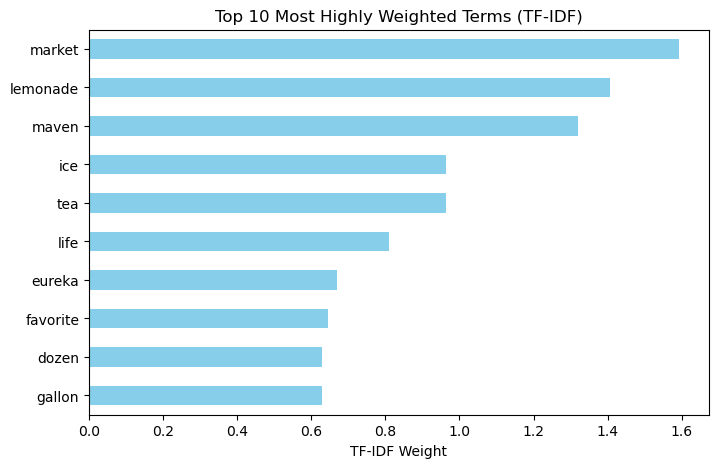

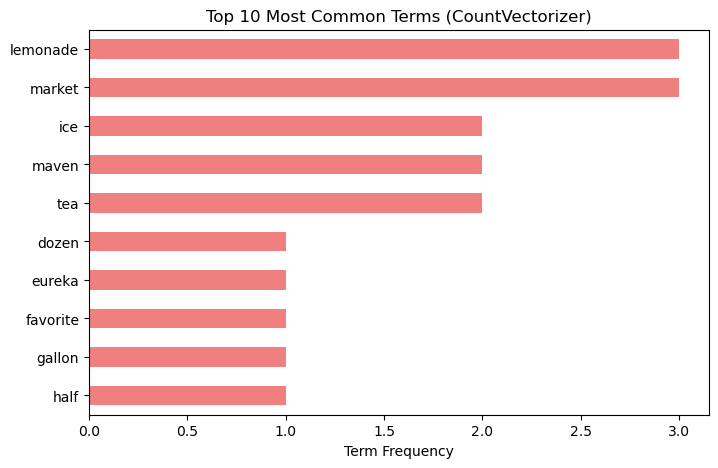


🔹 TF-IDF emphasizes unique, informative words.
🔹 CountVectorizer emphasizes frequent words regardless of uniqueness.
🔹 Comparing both charts reveals how weighting changes term importance.


In [12]:
# ---------------------------------------------
# 📘 Text Vectorization and Comparison Program
# ---------------------------------------------

# Imports
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt

# Sample cleaned text list
text_clean = [
    "life lemon lemonade",
    "lemon maven market",
    "dozen lemon gallon lemonade",
    "lemon lemon lemon lemon lemon lemon",
    "s market lemon sale today",
    "maven market eureka lemon lemon",
    "palmer lemonade half ice tea",
    "ice tea favorite"
]

# ---------------------------------------------
# 1️⃣ TF-IDF Vectorizer (default parameters)
# ---------------------------------------------
tv_default = TfidfVectorizer()
tfidf_default = tv_default.fit_transform(text_clean)
tfidf_df_default = pd.DataFrame(tfidf_default.toarray(), columns=tv_default.get_feature_names_out())
print("TF-IDF (default):")
display(tfidf_df_default.head())

# ---------------------------------------------
# 2️⃣ TF-IDF Vectorizer (parameter tweaks)
# ---------------------------------------------
tv_tuned = TfidfVectorizer(stop_words='english', min_df=0.1, max_df=0.5)
tfidf_tuned = tv_tuned.fit_transform(text_clean)
tfidf_df_tuned = pd.DataFrame(tfidf_tuned.toarray(), columns=tv_tuned.get_feature_names_out())
print("TF-IDF (tuned):")
display(tfidf_df_tuned.head())

# ---------------------------------------------
# 3️⃣ Top 10 most highly weighted terms
# ---------------------------------------------
term_weights = tfidf_df_tuned.sum().sort_values(ascending=False)
top10 = term_weights.head(10)

plt.figure(figsize=(8,5))
top10.plot(kind='barh', color='skyblue')
plt.title("Top 10 Most Highly Weighted Terms (TF-IDF)")
plt.xlabel("TF-IDF Weight")
plt.gca().invert_yaxis()
plt.show()

# ---------------------------------------------
# 4️⃣ Compare with CountVectorizer
# ---------------------------------------------
cv = CountVectorizer(stop_words='english', min_df=0.1, max_df=0.5)
count_matrix = cv.fit_transform(text_clean)
count_df = pd.DataFrame(count_matrix.toarray(), columns=cv.get_feature_names_out())

count_freq = count_df.sum().sort_values(ascending=False)
top10_count = count_freq.head(10)

plt.figure(figsize=(8,5))
top10_count.plot(kind='barh', color='lightcoral')
plt.title("Top 10 Most Common Terms (CountVectorizer)")
plt.xlabel("Term Frequency")
plt.gca().invert_yaxis()
plt.show()

# ---------------------------------------------
# 🧩 Comparison Summary
# ---------------------------------------------
print("\n🔹 TF-IDF emphasizes unique, informative words.")
print("🔹 CountVectorizer emphasizes frequent words regardless of uniqueness.")
print("🔹 Comparing both charts reveals how weighting changes term importance.")


#### Summary:

Text preprocessing

Text cleaning & normalization -> using Pandas and spaCy

Vectorization -> counts (Count Vectorizer) or TF-IDF scores (TF-IDF Vectorizer)

![nlp_with_ml](image-5.png)

#### COMMON ML ALGORITHMS

Just for recap

![common machine learning algorithms](image-1.png)

##### TRADITIONAL NLP OVERVIEW

Three foundational NLP tasks

##### **1. Sentiment Analysis**:

Identify whether text expresses a positive, negative, or neutral emotion. t helps businesses, researchers and developers to understand opinions and sentiments expressed in text data which is important for applications like social media monitoring, customer feedback analysis and more.

#### What is VADER & Uses ?

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a sentiment analysis tool which is designed to analyze social media text and informal language. Unlike traditional sentiment analysis methods it is best at detecting sentiment in short pieces of text like tweets, product reviews or user comments which contain slang, emojis and abbreviations. 

It uses compound score which is a normalized value between -1 and +1 representing the overall sentiment:

- Compound score > 0.05: Positive sentiment
- Compound score < -0.05: Negative sentiment
- Compound score between -0.05 and 0.05: Neutral sentiment

In [13]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()
print(analyzer.polarity_scores("I love lemonade!"))

{'neg': 0.0, 'neu': 0.308, 'pos': 0.692, 'compound': 0.6696}


In [14]:
def sentiment_scores(sentence):
    sid_obj = SentimentIntensityAnalyzer()
    sentiment_dict = sid_obj.polarity_scores(sentence)

    print(f"Sentiment Scores: {sentiment_dict}")
    print(f"Negative Sentiment: {sentiment_dict['neg']*100}%")
    print(f"Neutral Sentiment: {sentiment_dict['neu']*100}%")
    print(f"Positive Sentiment: {sentiment_dict['pos']*100}%")
    
    if sentiment_dict['compound'] >= 0.05:
        print("Overall Sentiment: Positive")
    elif sentiment_dict['compound'] <= -0.05:
        print("Overall Sentiment: Negative")
    else:
        print("Overall Sentiment: Neutral")

if __name__ == "__main__":

    sentence = "Geeks For Geeks is an excellent platform for CSE students."
    print("\n1st Statement:",sentence)
    sentiment_scores(sentence)

    
    sentence = "Shweta played well in the match as usual."
    print("\n2nd Statement:",sentence)
    sentiment_scores(sentence)

    
    sentence = "I am feeling sad today."
    print("\n3rd Statement:",sentence)
    sentiment_scores(sentence)
    
    sentence = "I do HATE those fake news on internet!!😡"
    print("\n4th Statement:",sentence)
    sentiment_scores(sentence)


1st Statement: Geeks For Geeks is an excellent platform for CSE students.
Sentiment Scores: {'neg': 0.207, 'neu': 0.519, 'pos': 0.274, 'compound': 0.4404}
Negative Sentiment: 20.7%
Neutral Sentiment: 51.9%
Positive Sentiment: 27.400000000000002%
Overall Sentiment: Positive

2nd Statement: Shweta played well in the match as usual.
Sentiment Scores: {'neg': 0.0, 'neu': 0.571, 'pos': 0.429, 'compound': 0.5423}
Negative Sentiment: 0.0%
Neutral Sentiment: 57.099999999999994%
Positive Sentiment: 42.9%
Overall Sentiment: Positive

3rd Statement: I am feeling sad today.
Sentiment Scores: {'neg': 0.408, 'neu': 0.395, 'pos': 0.197, 'compound': -0.3818}
Negative Sentiment: 40.8%
Neutral Sentiment: 39.5%
Positive Sentiment: 19.7%
Overall Sentiment: Negative

4th Statement: I do HATE those fake news on internet!!😡
Sentiment Scores: {'neg': 0.504, 'neu': 0.496, 'pos': 0.0, 'compound': -0.8449}
Negative Sentiment: 50.4%
Neutral Sentiment: 49.6%
Positive Sentiment: 0.0%
Overall Sentiment: Negative


#### 2. Text Classification

Classifying text as one label or another:

 - Technique: Supervised learning (i.e., Naïve Bayes)
 - Library: scikit-learn
 - Input format: CV / TF-IDF

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.decomposition import LatentDirichletAllocation

# Sample corpus
docs = [
    "Lemonade is refreshing in summer",
    "Tea and coffee are popular drinks",
    "Market sells lemons and oranges",
    "Sports events bring excitement",
]

# Step 1: Vectorize
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(docs)

# Step 2: Apply NMF for topic modeling
nmf = NMF(n_components=2, random_state=42)
W = nmf.fit_transform(X)
H = nmf.components_

# Step 2: Apply LDA
lda = LatentDirichletAllocation(n_components=2, random_state=42)
lda.fit(X)

# Step 3: Inspect topics
print('~~~~~~~~~~~~~ Inspect topics use method NMF ~~~~~~~~~~~~~~')
terms = vectorizer.get_feature_names_out()
for idx, topic in enumerate(H):
    top_terms = [terms[i] for i in topic.argsort()[-5:]]
    print(f"Topic {idx+1}: {top_terms}")

terms = vectorizer.get_feature_names_out()
print('~~~~~~~ Inspect topics use method lda ~~~~~~~~~')
for idx, topic in enumerate(lda.components_):
    top_terms = [terms[i] for i in topic.argsort()[-5:]]
    print(f"Topic {idx+1}: {top_terms}")

~~~~~~~~~~~~~ Inspect topics use method NMF ~~~~~~~~~~~~~~
Topic 1: ['tea', 'lemons', 'market', 'oranges', 'sells']
Topic 2: ['excitement', 'sports', 'lemonade', 'refreshing', 'summer']
~~~~~~~ Inspect topics use method lda ~~~~~~~~~
Topic 1: ['excitement', 'oranges', 'sells', 'lemons', 'market']
Topic 2: ['tea', 'popular', 'summer', 'lemonade', 'refreshing']


#### Summary:

##### ML vs NLP:

- Any general ML algorithm can be applied for NLP tasks once the text data is cleaned and vectorized
- ML is the preferred approach for small & medium data sets, while modern NLP is preferred for large ones.

##### Sentiment analysis:
- Popular libraries within Python for sentiment analysis include **VADER** and **TextBlob**
- Other techniques include text classification and modern NLP techniques

##### Naïve Bayes is a popular text classification technique:
- Naïve Bayes is a good starting point for classifying text data within small data sets (<10k rows)
- Other techniques include Logistic Regression, Gradient Boosted Trees, and modern NLP techniques



1️⃣ Text preprocessing  
• Update any cleaning or normalization steps

2️⃣ Vectorization  
• Fine‑tune CountVectorizer parameters (stop_words, ngram_range, min_df, etc.)
• Try using TfidfVectorizer instead

3️⃣ Feature engineering  
• Include non‑term values such as text length, sentiment score, time of day sent, etc.

4️⃣ Modeling  
- Try a different probability cutoff point instead of the default 50% probability
- Try a different classification model (Logistic Regression, Gradient Boosted Trees, etc.)

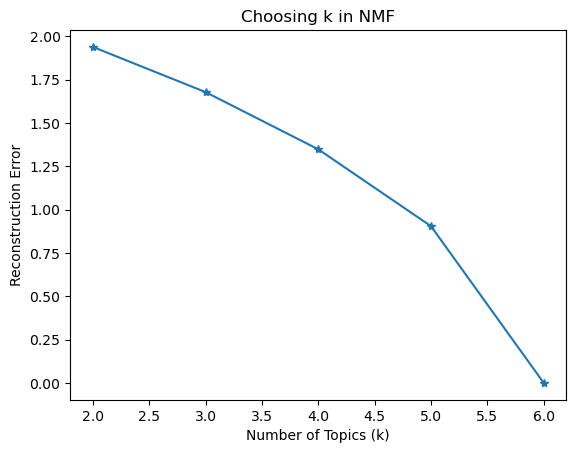

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
import matplotlib.pyplot as plt

# Sample corpus
docs = [
    "Lemonade and oranges are refreshing",
    "Tea and coffee are popular drinks",
    "Market sells fruits and vegetables",
    "Sports events bring excitement",
    "Football and cricket are famous games",
    "Healthy diet includes fruits and drinks"
]

# Step 1: Vectorize
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(docs)

# Step 2: Try multiple k values
errors = []
k_values = range(2, 7)  # test k = 2 to 6

for k in k_values:
    nmf = NMF(n_components=k, random_state=42, max_iter=500)
    W = nmf.fit_transform(X)
    H = nmf.components_
    # Reconstruction error
    errors.append(nmf.reconstruction_err_)

# Step 3: Plot error vs k
plt.plot(k_values, errors, marker='*')
plt.xlabel("Number of Topics (k)")
plt.ylabel("Reconstruction Error")
plt.title("Choosing k in NMF")
plt.show()


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Your docs variable
docs = [
    "Lemonade and oranges are refreshing",
    "Tea and coffee are popular drinks",    
]

# Step 1: Apply TF-IDF
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(docs)

# Step 2: Convert to DataFrame for readability
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

# Step 3: Print matrix
print(tfidf_df)


   coffee  drinks  lemonade  oranges  popular  refreshing  tea
0     0.0     0.0   0.57735  0.57735      0.0     0.57735  0.0
1     0.5     0.5   0.00000  0.00000      0.5     0.00000  0.5


Word embeddings (Word2Vec, GloVe, BERT)

Step 1: Text Preprocessing
- Clean raw text: remove punctuation, lowercase, normalize.
- Tokenize: split into words/tokens.
- Lemmatize/Stemming: reduce words to base form.
- Remove stopwords (e.g., "the", "is").
Result → clean text corpus.

Step 2: Text Vectorization
- Convert text into numerical features.
Common methods:
  - a) Bag-of-Words (CountVectorizer)
  - b) TF-IDF (Term Frequency-Inverse Document Frequency)
  - c) Word embeddings (Word2Vec, GloVe, BERT)
Result → Document-Term Matrix (DTM) or embedding matrix.

Step 3: Logistic Regression Modeling
- Logistic Regression predicts probability of class $y \in \{0,1\}$.
Formula:
$P(y=1|x) = \sigma(w^T x + b)$

Where:
- $x$ = feature vector (from TF-IDF or embeddings)
- $w$ = weight vector
- $b$ = bias term
- $\sigma(z) = \frac{1}{1+e^{-z}}$ (sigmoid function)

Decision rule:
$\hat{y} =
\begin{cases}
1 & \text{if } P(y=1|x) \geq 0.5 \\
0 & \text{otherwise}
\end{cases}$

Step 4: Training
- Optimize weights $w, b$ by minimizing loss:
$L = -\sum_{i=1}^{N} \big[ y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i) \big]$
(cross-entropy loss)

Step 5: Evaluation
- Use metrics: Accuracy, Precision, Recall, F1-score.
- Example in text classification: spam vs non-spam, sentiment analysis.


#### B.3 What are Word Embeddings?
Word embeddings are dense vector representations of words in a continuous vector space.

Unlike one‑hot encoding (sparse, high‑dimensional), embeddings capture semantic meaning: **words with similar meanings are close in the vector space**.

- Example:
    - "king" and "queen" → vectors close together.
    - "king" – "man" + "woman" ≈ "queen".

